In [1]:
# Compare ALL library-cluster configs (100k / 200k / 300k) for one seed.
# Auto-discovers every results/single_seq/foregrounds* dir that has data for SEQ_ID,
# so new configs (e.g. 300k) show up automatically once they finish.
import re
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

SEQ_ID = "peak26256"        # one of the seeds in seam_seeds.csv
R = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")

def _parse(name):
    """foregrounds[_<lib>k][_kmeans<N>] -> (lib_token, ism_suffix) or None."""
    m = re.fullmatch(r"foregrounds(?:_(\d+k))?(?:_kmeans(\d+))?", name)
    if m is None:
        return None
    lib = m.group(1) or "100k"               # bare 'foregrounds' is the 100k set
    suffix = "" if lib == "100k" else f"_{lib}"
    return lib, suffix

CONFIGS = {}   # label -> (foreground_dir_name, ism_suffix)
for d in sorted(R.glob("foregrounds*")):
    p = _parse(d.name)
    if p is None:
        continue
    lib, suffix = p
    lab = d / SEQ_ID / "cluster_labels.npy"
    ism = R / f"ism{suffix}" / f"{SEQ_ID}.h5"
    if not (lab.exists() and ism.exists()):
        continue                              # skip incomplete / missing-for-this-seed
    nc = int(np.load(lab).max()) + 1
    CONFIGS[f"{lib}_k{nc}"] = (d.name, suffix)

# order by library size, then cluster count
CONFIGS = dict(sorted(CONFIGS.items(),
                      key=lambda kv: (int(kv[0].split('_')[0][:-1]), int(kv[0].split('_k')[1]))))
print(f"{SEQ_ID}: {len(CONFIGS)} configs")
for k, v in CONFIGS.items():
    print(f"  {k:<12} {v[0]}")


peak26256: 14 configs
  100k_k50     foregrounds
  100k_k100    foregrounds_kmeans100
  100k_k200    foregrounds_kmeans200
  100k_k250    foregrounds_kmeans250
  100k_k300    foregrounds_kmeans300
  100k_k350    foregrounds_kmeans350
  100k_k400    foregrounds_kmeans400
  200k_k100    foregrounds_200k
  200k_k150    foregrounds_200k_kmeans150
  200k_k200    foregrounds_200k_kmeans200
  200k_k300    foregrounds_200k_kmeans300
  300k_k50     foregrounds_300k
  300k_k100    foregrounds_300k_kmeans100
  300k_k200    foregrounds_300k_kmeans200


In [2]:
# per-config cosine-sim distributions (member -> cluster centroid), ISM maps cached per library
_attr_cache = {}
def get_attr(suffix):
    if suffix not in _attr_cache:
        with h5py.File(R / f"ism{suffix}/{SEQ_ID}.h5") as f:
            _attr_cache[suffix] = f["ism_centered"][:]   # (N, 200, 4)
    return _attr_cache[suffix]

configs = list(CONFIGS)
wt_boxes, worst_boxes, avg_boxes = [], [], []
for cfg in configs:
    fg, suffix = CONFIGS[cfg]
    attr = get_attr(suffix)
    labels = np.load(R / fg / SEQ_ID / "cluster_labels.npy")
    cos = []
    for c in range(labels.max() + 1):
        m = attr[labels == c].reshape((labels == c).sum(), -1)
        ctr = m.mean(0)
        cos.append(m @ ctr / (np.linalg.norm(m, axis=1) * np.linalg.norm(ctr)))
    rng = np.array([c.max() - c.min() for c in cos])
    wt_boxes.append(cos[labels[0]])                       # WT cluster's member distribution
    worst_boxes.append(cos[rng.argmax()])                 # largest-range (least self-consistent) cluster
    avg_boxes.append(np.array([c.mean() for c in cos]))   # per-cluster mean -> distribution across clusters
print("done")


done


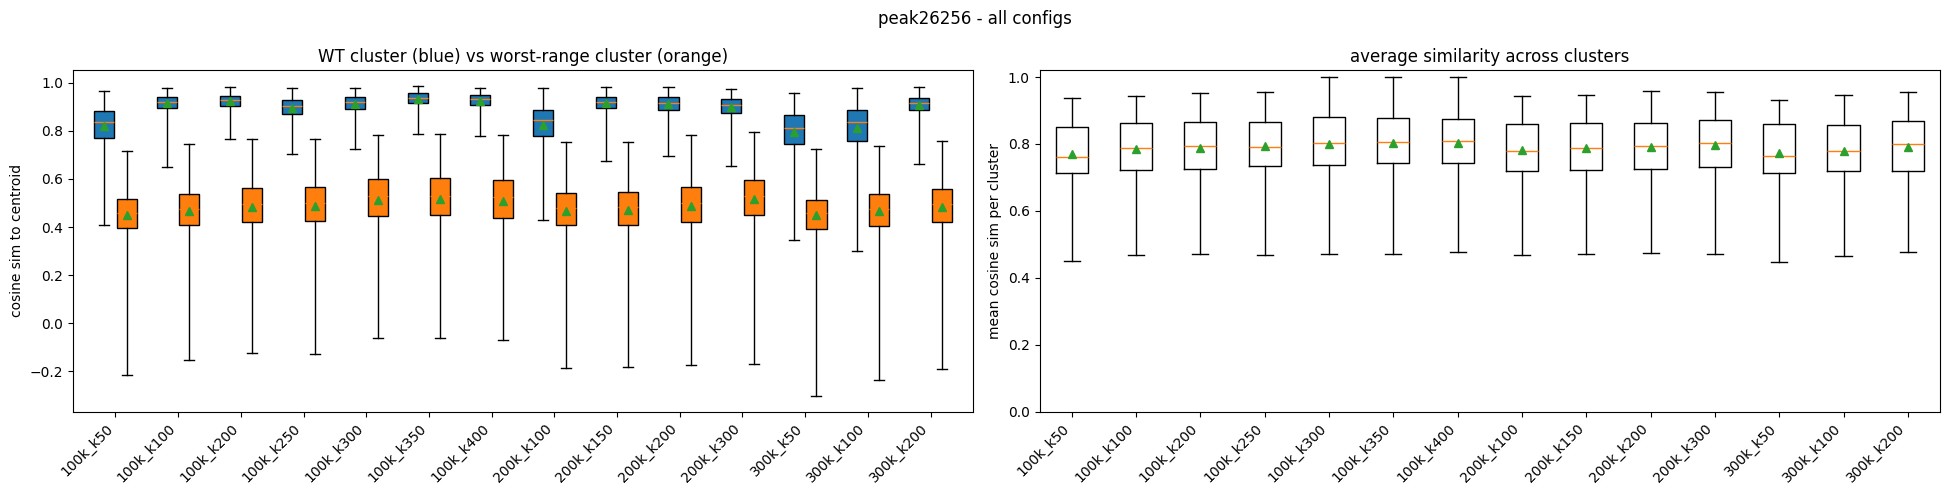

In [3]:
# (left) WT cluster vs worst-range cluster ; (right) average similarity across clusters
fig, axes = plt.subplots(1, 2, figsize=(max(14, 1.4 * len(configs)), 5))
pos = np.arange(len(configs))

axes[0].boxplot(wt_boxes, positions=pos - 0.18, widths=0.32, showmeans=True, showfliers=False,
                whis=(0, 100), patch_artist=True, boxprops=dict(facecolor="C0"))
axes[0].boxplot(worst_boxes, positions=pos + 0.18, widths=0.32, showmeans=True, showfliers=False,
                whis=(0, 100), patch_artist=True, boxprops=dict(facecolor="C1"))
axes[0].set_xticks(pos); axes[0].set_xticklabels(configs, rotation=45, ha="right")
axes[0].set_ylabel("cosine sim to centroid")
axes[0].set_title("WT cluster (blue) vs worst-range cluster (orange)")

axes[1].boxplot(avg_boxes, positions=pos, showmeans=True, showfliers=False, whis=(0, 100))
axes[1].set_xticks(pos); axes[1].set_xticklabels(configs, rotation=45, ha="right")
axes[1].set_ylabel("mean cosine sim per cluster")
axes[1].set_title("average similarity across clusters")
axes[1].set_ylim(0, 1.02)

fig.suptitle(f"{SEQ_ID} - all configs")
plt.tight_layout()
